# Introduction to Meta-heuristics: Team Work I  - Partition Problem


## Team Members
1. m5291087 Tithira Withanaarachchi
2. m5291501 Minnah Aamir
3. s1300030 Kohei Kuwana


## Role of Each Member.

*   **Kohei Kuwana:** Apply TS, SA, ILS and GLS to the Partition Problem: Includes coding, testing, Creating Presentation slides, Reviewing Report and Presentation slides.

*   **Minnah Amir:** Apply TS, SA, ILS and GLS to Knapsack problem: Includes coding, testing, Documenting with explanations, Creating Presentation Slides, Reviewing Report and Presentation slides.

*   **Tithira Withanaarachchi:** Co-ordinating work, Parameter Optimization of the application of TS, SA, ILS and GLS algorithms to Partition Problem: Includes research and learning what and how parameter optimization is done from the scratch and learning optuna, coding, testing, Documenting with explanations, Creating Presentation Slides, Reviewing Report and Presentation slides.













# 1. Problem Introduction




## 1.1 Partition Problem
Given $N$ integers ($A_1, A_2, …, A_N$), divide them into 2 subsets ($S_1,S_2$), and minimize the difference between their their sums. (Minimize $|sum(S_1)-sum(S_2)|$)

## 1.2 Example

$A = [3, 1, 4, 2, 2]$

Divide 2 subsets

$S_1 = [3,1,2], S_2 = [4,2]$

$sum(S_1) = 6, sum(S_2) = 6$

In this case, the answer is best, because the difference is 0.


# 2. Application of Algorithms

## 2.0 Initialization

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 5.7 MB/s eta 0:00:00


In [ ]:
import math, random, time, tracemalloc, statistics as stats
import optuna

# --Objective Function--
# Calculate the difference S_1 and S_2
def cost(sol, vals):
    s1 = sum(v for v, x in zip(vals, sol) if x == 0)
    s2 = sum(v for v, x in zip(vals, sol) if x == 1)
    return abs(s1 - s2)

# Init random 0/1
def init_solution(n, rng):
    return [rng.randint(0,1) for _ in range(n)]


In [ ]:
# --General--
def run_with_metrics(fn, *args, **kwargs):
    tracemalloc.start()
    t0 = time.perf_counter()
    sol, best = fn(*args, **kwargs)
    t1 = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return {"value": float(best), "time_s": t1-t0, "mem_mib": peak/(1024*1024)}

def summarize(records):
    def agg(key):
        xs = [r[key] for r in records]
        return min(xs), max(xs), sum(xs)/len(xs)
    return agg("value"), agg("time_s"), agg("mem_mib")

def print_table(name, mv, mt, mm):
    def f3(t): return f"{t[0]:.6f} / {t[1]:.6f} / {t[2]:.6f}"
    print(f"\n=== {name} (min / max / avg) ===")
    print(f"Objective : {f3(mv)}")
    print(f"Time [s]  : {f3(mt)}")
    print(f"Peak MiB  : {f3(mm)}")

In [ ]:
# Generate Problem
N = 10000
RNG_SEED = 42
rnd = random.Random(RNG_SEED)
vals = [rnd.randint(1, 10000) for _ in range(N)]
#print(vals)

## 2.1 TS



**2.1.1 Without Parameter Optimization.**

In [ ]:
def tabu_search(vals, seed=0, max_iter=20000, tabu_tenure=10, no_improve_limit=2000, restart_tries=2):
    rnd = random.Random(seed)
    n = len(vals)

    sol = init_solution(n,rnd)
    sum0 = sum(v for v, x in zip(vals, sol) if x == 0)
    sum1 = sum(v for v, x in zip(vals, sol) if x == 1)
    diff = cost(sol,vals)

    best_sol = sol[:]
    best_diff = diff

    tabu_until = [ -1 ] * n

    it = 0
    stall = 0
    restarts_done = 0

    while it < max_iter:
        it += 1

        # flip sol[i](A_i) and search better solution
        curr_gap = sum0 - sum1
        best_move = None
        best_move_newdiff = None

        for i, v in enumerate(vals):
            # flip sol[i]
            if sol[i] == 0:
                newdiff = abs(curr_gap - 2*v)  # S1->S2
            else:
                newdiff = abs(curr_gap + 2*v)  # S2->S1

            # Judge Tabu
            is_tabu = it < tabu_until[i]
            aspiration = newdiff < best_diff

            if (not is_tabu) or aspiration:
                if (best_move_newdiff is None) or (newdiff < best_move_newdiff):
                    best_move_newdiff = newdiff
                    best_move = i

        # Quickest tabu removal if Intensify
        if best_move is None:
            idx = min(range(n), key=lambda k: tabu_until[k])
            best_move = idx
            if sol[idx] == 0:
                best_move_newdiff = abs(curr_gap - 2*vals[idx])
            else:
                best_move_newdiff = abs(curr_gap + 2*vals[idx])

        # Apply
        i = best_move
        v = vals[i]
        old_bit = sol[i]
        sol[i] = 1 - sol[i]
        if old_bit == 0:
            sum0 -= v; sum1 += v
        else:
            sum0 += v; sum1 -= v
        diff = best_move_newdiff

        # Update Tabu
        tabu_until[i] = it + tabu_tenure + (rnd.randrange(3) - 1)  # ±1

        # Update best solution
        if diff < best_diff:
            best_diff = diff
            best_sol = sol[:]
            stall = 0
        else:
            stall += 1

        # Diversify
        if stall >= no_improve_limit:
            stall = 0
            restarts_done += 1
            if restarts_done > restart_tries:
                continue

            # k-bit random reverse
            k = max(1, n // 20)
            picks = rnd.sample(range(n), k)
            for j in picks:
                bit = sol[j]
                sol[j] = 1 - bit
                if bit == 0:
                    sum0 -= vals[j]; sum1 += vals[j]
                else:
                    sum0 += vals[j]; sum1 -= vals[j]
            diff = cost(sol,vals)
            tabu_until = [ -1 ] * n

        # Terminate (best_diff == 0)
        if best_diff == 0:
            break

    return best_sol, best_diff

In [ ]:
# Tabu Search (10 times)
TS_RECS = []
for i in range(10):
    rec = run_with_metrics(
        tabu_search,
        vals,
        seed=1000+i,
        max_iter=30_000,
        tabu_tenure=12,
        no_improve_limit=3_000,
        restart_tries=2
    )
    TS_RECS.append(rec)

mv, mt, mm = summarize(TS_RECS)
print_table("Tabu Search (Partition)", mv, mt, mm)


=== Tabu Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.988289 / 6.781431 / 2.748208
Peak MiB  : 0.313110 / 0.313110 / 0.313110


**2.1.2 With Parameter Optimization**

In [ ]:
def obj_tabu(trial: optuna.Trial) -> float:
  tabu_tenure = trial.suggest_int("tabu_tenure", 5, 50)
  noimp_frac = trial.suggest_categorical("no_improve_frac", [0.02, 0.05, 0.1, 0.2, 0.3])
  max_iters = 30000
  no_improve_limit = max(50, int(noimp_frac * max_iters))
  restart_tries = trial.suggest_int("restart_tries", 0, 2)
  seed = trial.suggest_int("seed", 1, 10)
  # tracemalloc.start()
  t0 = time.perf_counter()

  _, best_diff = tabu_search(
    vals,
    seed,
    max_iters,
    tabu_tenure,
    no_improve_limit,
    restart_tries
  )

  elapsed = time.perf_counter() - t0
  # _, peak = tracemalloc.get_traced_memory()
  # tracemalloc.stop()

  trial.set_user_attr("elapsed_s", elapsed)
  # trial.set_user_attr("peak_mib", peak / (1024**2))

  if best_diff == 0:
        return elapsed                  # minimize runtime if solution is perfect
  else:
      return 1e9 + float(best_diff)   # heavy penalty for incorrect result

In [ ]:
OPT_TS_RECS = []
def run(name, obj, trials=120):
    print(f"\n=== {name} ===")
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=7),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
        study_name=name,
    )

    study.optimize(obj, n_trials=trials)
    params=study.best_params

    print("Best params:", params)


    for i in range(10):
      rec = run_with_metrics(
          tabu_search,
          vals,
          seed= params["seed"],
          max_iter= 30_000,
          tabu_tenure=params["tabu_tenure"],
          no_improve_limit=params["no_improve_frac"] * 30_000,
          restart_tries=params["restart_tries"]
      )
      OPT_TS_RECS.append(rec)

    mv, mt, mm = summarize(OPT_TS_RECS)
    print_table("Tabu Search (Partition)", mv, mt, mm)

In [ ]:
run("TS_on_Partition Problem", obj_tabu, trials=120)

[I 2025-11-06 06:17:22,184] A new study created in memory with name: TS_on_Partition Problem
[I 2025-11-06 06:17:22,244] Trial 0 finished with value: 0.05759116100000483 and parameters: {'tabu_tenure': 8, 'no_improve_frac': 0.2, 'restart_tries': 1, 'seed': 1}. Best is trial 0 with value: 0.05759116100000483.



=== TS_on_Partition Problem ===


[I 2025-11-06 06:17:22,434] Trial 1 finished with value: 0.18644468700000516 and parameters: {'tabu_tenure': 17, 'no_improve_frac': 0.1, 'restart_tries': 0, 'seed': 10}. Best is trial 0 with value: 0.05759116100000483.
[I 2025-11-06 06:17:22,529] Trial 2 finished with value: 0.09280080499996757 and parameters: {'tabu_tenure': 14, 'no_improve_frac': 0.3, 'restart_tries': 0, 'seed': 6}. Best is trial 0 with value: 0.05759116100000483.
[I 2025-11-06 06:17:22,706] Trial 3 finished with value: 0.17515608700000485 and parameters: {'tabu_tenure': 46, 'no_improve_frac': 0.1, 'restart_tries': 0, 'seed': 5}. Best is trial 0 with value: 0.05759116100000483.
[I 2025-11-06 06:17:22,900] Trial 4 finished with value: 0.18919769599995107 and parameters: {'tabu_tenure': 22, 'no_improve_frac': 0.1, 'restart_tries': 1, 'seed': 3}. Best is trial 0 with value: 0.05759116100000483.
[I 2025-11-06 06:17:23,067] Trial 5 finished with value: 0.16457168700003422 and parameters: {'tabu_tenure': 25, 'no_improve_fr

Best params: {'tabu_tenure': 9, 'no_improve_frac': 0.02, 'restart_tries': 2, 'seed': 7}

=== Tabu Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.308708 / 0.623600 / 0.438326
Peak MiB  : 0.313080 / 0.314055 / 0.313177


## 2.2 SA

**2.2.1 Without Parameter Optimization.**

In [ ]:
def simulated_annealing(vals, seed=0, T0=1.0, alpha=0.995, iters=20000):
    rnd = random.Random(seed)
    n = len(vals)

    sol = init_solution(n,rnd)
    s0 = sum(v for v, x in zip(vals, sol) if x == 0)
    s1 = sum(v for v, x in zip(vals, sol) if x == 1)
    curr = cost(sol,vals)

    best = curr
    best_sol = sol[:]

    T = T0
    for t in range(iters):
        i = rnd.randrange(n)
        v = vals[i]
        gap = s0 - s1
        new = abs(gap - 2*v) if sol[i]==0 else abs(gap + 2*v)
        dE = new - curr

        # Accept Bad solution randomly(T)
        if dE <= 0 or rnd.random() < math.exp(-dE / max(T, 1e-12)):
            # Update solution
            if sol[i]==0:
                s0 -= v; s1 += v
            else:
                s0 += v; s1 -= v
            sol[i] = 1 - sol[i]
            curr = new

            if curr < best:
                best = curr
                best_sol = sol[:]
                if best == 0:  # Terminate
                    break

        T *= alpha

    return best_sol, float(best)

In [ ]:
SA_RECS = []
for i in range(10):
    SA_RECS.append(run_with_metrics(
        simulated_annealing,
        vals,
        seed=2000+i,
        T0=1.0,
        alpha=0.9995,
        iters=200_000
    ))

mv, mt, mm = summarize(SA_RECS)
print_table("Simulated Annealing (Partition)", mv, mt, mm)


=== Simulated Annealing (Partition) (min / max / avg) ===
Objective : 0.000000 / 2.000000 / 1.800000
Time [s]  : 0.054174 / 4.139583 / 2.818405
Peak MiB  : 0.236816 / 0.238208 / 0.236959


**2.2.2 With Parameter Optimization.**

In [ ]:
def obj_sa(trial: optuna.Trial) -> float:
  init_temp = trial.suggest_float("init_temp", 0.1, 50.0, log=True)
  alpha = trial.suggest_float("alpha",0.85,0.9999)
  iters = trial.suggest_int("iters", 1000, 20000, log=True)
  seed = trial.suggest_int("seed", 1, 10)
  t0 = time.perf_counter()
  _, best = simulated_annealing(
    vals,
    seed,
    init_temp,
    alpha,
    iters,
  )

  elapsed = time.perf_counter() - t0

  if best == 0:
        return elapsed                  # minimize runtime if solution is perfect
  else:
      return 1e9 + float(best)

In [ ]:
OPT_SA_RECS = []
def run(name, obj, trials=120):
    print(f"\n=== {name} ===")
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=7),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
        study_name=name,
    )
    study.optimize(obj, n_trials=trials)

    params = study.best_params
    print("Best params:", params)


    for i in range(10):
        OPT_SA_RECS.append(run_with_metrics(
            simulated_annealing,
            vals,
            params["seed"],
            params["init_temp"],
            params["alpha"],
            params["iters"]
        ))

    mv, mt, mm = summarize(OPT_SA_RECS)
    print_table("Simulated Annealing (Partition)", mv, mt, mm)

In [ ]:
run("SA_on_Partition Problem", obj_sa, trials=120)

[I 2025-11-06 06:18:08,789] A new study created in memory with name: SA_on_Partition Problem
[I 2025-11-06 06:18:08,802] Trial 0 finished with value: 0.010407130999965375 and parameters: {'init_temp': 0.1606770257792105, 'alpha': 0.9669098269567932, 'iters': 3718, 'seed': 8}. Best is trial 0 with value: 0.010407130999965375.
[I 2025-11-06 06:18:08,820] Trial 1 finished with value: 1000000004.0 and parameters: {'init_temp': 43.60781809702198, 'alpha': 0.930720530974524, 'iters': 4486, 'seed': 1}. Best is trial 0 with value: 0.010407130999965375.
[I 2025-11-06 06:18:08,839] Trial 2 finished with value: 1000000002.0 and parameters: {'init_temp': 0.5302842829460648, 'alpha': 0.9249323868737515, 'iters': 7650, 'seed': 9}. Best is trial 0 with value: 0.010407130999965375.
[I 2025-11-06 06:18:08,856] Trial 3 finished with value: 1000000004.0 and parameters: {'init_temp': 1.0669613601198482, 'alpha': 0.8598838584011952, 'iters': 2370, 'seed': 10}. Best is trial 0 with value: 0.0104071309999653


=== SA_on_Partition Problem ===


[I 2025-11-06 06:18:08,979] Trial 10 finished with value: 1000000004.0 and parameters: {'init_temp': 0.23913018605592917, 'alpha': 0.9820232024236413, 'iters': 1121, 'seed': 7}. Best is trial 0 with value: 0.010407130999965375.
[I 2025-11-06 06:18:09,009] Trial 11 finished with value: 1000000002.0 and parameters: {'init_temp': 25.1368638070334, 'alpha': 0.9654150781116011, 'iters': 9968, 'seed': 7}. Best is trial 0 with value: 0.010407130999965375.
[I 2025-11-06 06:18:09,035] Trial 12 finished with value: 0.013405602000034378 and parameters: {'init_temp': 2.634815706326258, 'alpha': 0.8612387106974637, 'iters': 3422, 'seed': 8}. Best is trial 0 with value: 0.010407130999965375.
[I 2025-11-06 06:18:09,065] Trial 13 finished with value: 1000000010.0 and parameters: {'init_temp': 0.100069095312363, 'alpha': 0.9610986657235019, 'iters': 7202, 'seed': 5}. Best is trial 0 with value: 0.010407130999965375.
[I 2025-11-06 06:18:09,101] Trial 14 finished with value: 1000000002.0 and parameters: 

Best params: {'init_temp': 1.038858255584974, 'alpha': 0.9382951648044459, 'iters': 19054, 'seed': 4}

=== Simulated Annealing (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.026556 / 0.032836 / 0.028097
Peak MiB  : 0.236702 / 0.239053 / 0.237156


## 2.3 ILS

**2.3.1 Without Parameter Optimization.**

In [ ]:
# Search a better solution to flip (use/don't use) one bit from current solution.
def _best_improving_flip(sol, vals, sum0, sum1):
    n = len(vals)
    gap = sum0 - sum1
    best_i = None
    curr = cost(sol, vals)
    best_new = curr

    for i, v in enumerate(vals):
        new = abs(gap - 2*v) if sol[i]==0 else abs(gap + 2*v)
        if new < best_new:
            best_new = new
            best_i = i

    return best_i, best_new

# Flip A_i (use/don't use)
def _apply_flip_inplace(sol, i, vals, sum0, sum1):
    v = vals[i]
    if sol[i] == 0:
        sum0 -= v; sum1 += v
    else:
        sum0 += v; sum1 -= v
    sol[i] = 1 - sol[i]
    return sum0, sum1

# Local Search
def _local_descent(sol, vals, sum0, sum1, max_steps=10_000):
    steps = 0
    while steps < max_steps:
        i, new_cost = _best_improving_flip(sol, vals, sum0, sum1)
        curr = cost(sol, vals)
        if i is None or new_cost >= curr:
            break
        sum0, sum1 = _apply_flip_inplace(sol, i, vals, sum0, sum1)
        steps += 1
        if new_cost == 0:
            break
    return sol, sum0, sum1, cost(sol, vals)

# Flip k bits (use/don't use) randomly
def _perturb_k(sol, vals, sum0, sum1, k, rnd):
    n = len(vals)
    k = min(k, n)
    idxs = rnd.sample(range(n), k)
    for j in idxs:
        sum0, sum1 = _apply_flip_inplace(sol, j, vals, sum0, sum1)
    return sol, sum0, sum1

In [ ]:
def ILS(vals, seed=0, outer_iters=20000, k_perturb=4, ls_cap=10_000,
        accept_worse_prob=0.05, stagnation_limit=50):

    rnd = random.Random(seed)
    n = len(vals)

    sol = init_solution(n,rnd)
    sum0 = sum(v for v, x in zip(vals, sol) if x == 0)
    sum1 = sum(v for v, x in zip(vals, sol) if x == 1)
    sol, sum0, sum1, curr = _local_descent(sol, vals, sum0, sum1, max_steps=ls_cap)

    best_sol = sol[:]
    best = curr
    no_improve = 0

    for it in range(outer_iters):
        # Perturbation
        k = k_perturb if no_improve < stagnation_limit else max(k_perturb*2, 3)
        cand = best_sol[:]  # search around current best solutions
        sum0_c = sum(v for v, x in zip(vals, cand) if x == 0)
        sum1_c = sum(v for v, x in zip(vals, cand) if x == 1)
        cand, sum0_c, sum1_c = _perturb_k(cand, vals, sum0_c, sum1_c, k, rnd)

        # Research
        cand, sum0_c, sum1_c, c = _local_descent(cand, vals, sum0_c, sum1_c, max_steps=ls_cap)

        # Accept
        if c < best or (c > best and rnd.random() < accept_worse_prob):
            best, best_sol = c, cand[:]
            no_improve = 0
        else:
            no_improve += 1

        if best == 0:
            break

    return best_sol, float(best)

In [ ]:
ILS_RECS = []
for i in range(10):
    ILS_RECS.append(run_with_metrics(
        ILS, vals,
        seed=3000+i,
        outer_iters=400,
        k_perturb=5,
        ls_cap=12_000,
        accept_worse_prob=0.05,
        stagnation_limit=60
    ))

mv, mt, mm = summarize(ILS_RECS)
print_table("Iterated Local Search (Partition)", mv, mt, mm)


=== Iterated Local Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.558494 / 3.155287 / 1.420642
Peak MiB  : 0.237896 / 0.312939 / 0.253079


**2.3.2 With Parameter Optimization.**

In [ ]:
def obj_ILS(trial: optuna.Trial) -> float:
  ls_cap = trial.suggest_int("ls_cap", 10000, 50000, log=True)
  k_perturb = trial.suggest_int("k_perturb", 1, 10)
  seed = trial.suggest_int("seed", 1, 10)
  accept_worse_prob = trial.suggest_categorical("accept_worse_prob", [0.0, 0.02, 0.05, 0.1])
  stagnation_limit = trial.suggest_categorical("stagnation_limit", [15, 25, 40, 60, 80, 120])


  t0 = time.perf_counter()
  _, best = ILS(
    vals,
    seed,
    20000,
    k_perturb,
    ls_cap,
    accept_worse_prob,
    stagnation_limit,
  )

  elapsed = time.perf_counter() - t0

  if best == 0:
        return elapsed                  # minimize runtime if solution is perfect
  else:
      return 1e9 + float(best)

In [ ]:
OPT_ILS_RECS = []
def run(name, obj, trials=120):
    print(f"\n=== {name} ===")
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=7),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
        study_name=name,
    )
    study.optimize(obj, n_trials=trials)

    params = study.best_params
    print("\nBest params:", params)


    for i in range(10):
        OPT_ILS_RECS.append(run_with_metrics(
            ILS,
            vals,
            params["seed"],
            20000,
            params["k_perturb"],
            params["ls_cap"],
            params["accept_worse_prob"],
            params["stagnation_limit"]
        ))

    mv, mt, mm = summarize(OPT_ILS_RECS)
    print_table("Iterative Local Search (Partition)", mv, mt, mm)

In [ ]:
run("ILS_on_Partition Problem", obj_ILS, trials=120)

[I 2025-11-06 06:18:26,487] A new study created in memory with name: ILS_on_Partition Problem
[I 2025-11-06 06:18:26,656] Trial 0 finished with value: 0.16426503599996067 and parameters: {'ls_cap': 11306, 'k_perturb': 8, 'seed': 5, 'accept_worse_prob': 0.02, 'stagnation_limit': 80}. Best is trial 0 with value: 0.16426503599996067.



=== ILS_on_Partition Problem ===


[I 2025-11-06 06:18:26,955] Trial 1 finished with value: 0.29677544300000136 and parameters: {'ls_cap': 11119, 'k_perturb': 3, 'seed': 10, 'accept_worse_prob': 0.05, 'stagnation_limit': 25}. Best is trial 0 with value: 0.16426503599996067.
[I 2025-11-06 06:18:27,071] Trial 2 finished with value: 0.1134634939999728 and parameters: {'ls_cap': 23219, 'k_perturb': 8, 'seed': 7, 'accept_worse_prob': 0.05, 'stagnation_limit': 40}. Best is trial 2 with value: 0.1134634939999728.
[I 2025-11-06 06:18:27,203] Trial 3 finished with value: 0.12947985699997844 and parameters: {'ls_cap': 15593, 'k_perturb': 5, 'seed': 4, 'accept_worse_prob': 0.1, 'stagnation_limit': 25}. Best is trial 2 with value: 0.1134634939999728.
[I 2025-11-06 06:18:27,379] Trial 4 finished with value: 0.17326036200000772 and parameters: {'ls_cap': 27759, 'k_perturb': 6, 'seed': 5, 'accept_worse_prob': 0.05, 'stagnation_limit': 25}. Best is trial 2 with value: 0.1134634939999728.
[I 2025-11-06 06:18:27,682] Trial 5 finished wit


Best params: {'ls_cap': 34875, 'k_perturb': 8, 'seed': 9, 'accept_worse_prob': 0.1, 'stagnation_limit': 60}

=== Iterative Local Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.409576 / 0.431517 / 0.421211
Peak MiB  : 0.312939 / 0.313931 / 0.313038


## 2.4: GLS

**2.4.1 Without Parameter Optimization.**

In [ ]:
def GLS(vals, seed=0, outer_iters=200, ls_cap=50_000, alpha=0.3):
    rnd = random.Random(seed)
    n = len(vals)
    if n == 0:
        return [], 0.0

    sol = init_solution(n,rnd)
    sum0 = sum(v for v, x in zip(vals, sol) if x == 0)
    sum1 = sum(v for v, x in zip(vals, sol) if x == 1)
    true_cost = cost(sol,vals)
    best_true = true_cost
    best_sol = sol[:]

    # Penalty
    p = [0] * n
    pen0 = sum((pi * v) for (pi, v, x) in zip(p, vals, sol) if x == 0)
    pen1 = sum((pi * v) for (pi, v, x) in zip(p, vals, sol) if x == 1)

    # Setting λ
    lam = alpha * (true_cost / max(1, n))

    def aug_cost(gap, pen0, pen1):
        # gap>=0 ? S0 is heavy : S1 is heavy
        return abs(gap) + lam * (pen0 if gap >= 0 else pen1)

    # Local Search
    def local_search_aug(sol, sum0, sum1, p, pen0, pen1, cap):
        steps = 0
        while steps < cap:
            steps += 1
            gap = sum0 - sum1
            curr_aug = aug_cost(gap, pen0, pen1)

            best_i = None
            best_new_aug = curr_aug

            for i, v in enumerate(vals):
                # Calc new_gap to flip a bit
                new_gap = gap - 2*v if sol[i] == 0 else gap + 2*v

                # Update Penalty
                pi_v = p[i] * v
                if sol[i] == 0:
                    new_pen0 = pen0 - pi_v
                    new_pen1 = pen1 + pi_v
                else:
                    new_pen0 = pen0 + pi_v
                    new_pen1 = pen1 - pi_v

                new_aug = aug_cost(new_gap, new_pen0, new_pen1)
                if new_aug < best_new_aug:
                    best_new_aug = new_aug
                    best_i = i

            if best_i is None:  # Local opt
                break

            # Update best solution
            i = best_i
            v = vals[i]
            if sol[i] == 0:
                sum0 -= v; sum1 += v
                pen0 -= p[i] * v; pen1 += p[i] * v
            else:
                sum0 += v; sum1 -= v
                pen0 += p[i] * v; pen1 -= p[i] * v
            sol[i] = 1 - sol[i]

        return sol, sum0, sum1, pen0, pen1

    # --- GLS Loop ---
    for _ in range(outer_iters):
        # Local search and ppdate solution
        sol, sum0, sum1, pen0, pen1 = local_search_aug(sol, sum0, sum1, p, pen0, pen1, ls_cap)

        tc = abs(sum0 - sum1)
        if tc < best_true:
            best_true = tc
            best_sol = sol[:]
            if best_true == 0:
                break

        # Update Utility and Penalty
        gap = sum0 - sum1
        heavier_side = 0 if gap >= 0 else 1
        utilities = []
        for i, v in enumerate(vals):
            on_heavy = (sol[i] == heavier_side)
            feat = v if on_heavy else 0
            util = feat / (1 + p[i]) if feat > 0 else 0.0
            utilities.append(util)

        max_u = max(utilities) if utilities else 0.0
        if max_u == 0.0:
            j = rnd.randrange(n)
            p[j] += 1
            if sol[j] == 0: pen0 += vals[j]
            else:           pen1 += vals[j]
        else:
            for i, u in enumerate(utilities):
                if u == max_u:
                    p[i] += 1
                    if sol[i] == 0: pen0 += vals[i]
                    else:           pen1 += vals[i]

    return best_sol, float(best_true)

In [ ]:
GLS_RECS = []
for i in range(10):
    GLS_RECS.append(run_with_metrics(
        GLS, vals,
        seed=4000+i,
        outer_iters=200,
        ls_cap=60_000,
        alpha=0.3
    ))

mv, mt, mm = summarize(GLS_RECS)
print_table("Guided Local Search (Partition)", mv, mt, mm)


=== Guided Local Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 2.000000 / 0.200000
Time [s]  : 0.479590 / 49.299412 / 6.106292
Peak MiB  : 0.313442 / 0.507423 / 0.344992


**2.4.2 With Parameter Optimization.**

In [ ]:
def obj_GLS(trial: optuna.Trial) -> float:
  ls_cap = trial.suggest_int("ls_cap", 500, 50000, log=True)
  alpha = trial.suggest_float("alpha",0.85,0.9999)
  outer_iters = trial.suggest_int("outer_iters", 200, 5000, log=True)
  seed = trial.suggest_int("seed", 1, 500)

  t0 = time.perf_counter()
  _, best = GLS(
    vals,
    seed,
    outer_iters,
    ls_cap,
    alpha
  )

  elapsed = time.perf_counter() - t0

  if best == 0:
        return elapsed                  # minimize runtime if solution is perfect
  else:
      return 1e9 + float(best)

In [ ]:
OPT_GLS_RECS = []
def run(name, obj, trials=120):
    print(f"\n=== {name} ===")
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=7),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
        study_name=name,
    )
    study.optimize(obj, n_trials=trials)

    params = study.best_params
    print("\nBest params:", params)


    for i in range(10):
        OPT_GLS_RECS.append(run_with_metrics(
            GLS,
            vals,
            params["seed"],
            params["outer_iters"],
            params["ls_cap"],
            params["alpha"]
        ))

    mv, mt, mm = summarize(OPT_GLS_RECS)
    print_table("Guided Local Search (Partition)", mv, mt, mm)

In [ ]:
run("GLS_on_Partition Problem", obj_GLS, trials=120)

[I 2025-11-06 06:19:50,314] A new study created in memory with name: GLS_on_Partition Problem



=== GLS_on_Partition Problem ===


[I 2025-11-06 06:19:58,558] Trial 0 finished with value: 1000000002.0 and parameters: {'ls_cap': 710, 'alpha': 0.9669098269567932, 'outer_iters': 819, 'seed': 362}. Best is trial 0 with value: 1000000002.0.
[I 2025-11-06 06:19:58,814] Trial 1 finished with value: 0.25321257100000594 and parameters: {'ls_cap': 45180, 'alpha': 0.930720530974524, 'outer_iters': 1002, 'seed': 37}. Best is trial 1 with value: 0.25321257100000594.
[I 2025-11-06 06:19:58,963] Trial 2 finished with value: 0.14622792500000514 and parameters: {'ls_cap': 1720, 'alpha': 0.9249323868737515, 'outer_iters': 1779, 'seed': 402}. Best is trial 2 with value: 0.14622792500000514.
[I 2025-11-06 06:19:59,021] Trial 3 finished with value: 0.054943850000029215 and parameters: {'ls_cap': 2888, 'alpha': 0.8598838584011952, 'outer_iters': 505, 'seed': 455}. Best is trial 3 with value: 0.054943850000029215.
[I 2025-11-06 06:19:59,194] Trial 4 finished with value: 0.17049759899998662 and parameters: {'ls_cap': 1335, 'alpha': 0.917


Best params: {'ls_cap': 5296, 'alpha': 0.8661802649057001, 'outer_iters': 216, 'seed': 188}

=== Guided Local Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.148241 / 0.165116 / 0.154228
Peak MiB  : 0.313328 / 0.314255 / 0.313500


# 3. Discussion

**3.1 Discussion of Results of Algorithms.**

In [ ]:
# --Results (Reprinted)--
# TS
mv, mt, mm = summarize(TS_RECS)
print_table("Tabu Search (Partition)", mv, mt, mm)

# SA
mv, mt, mm = summarize(SA_RECS)
print_table("Simulated Annealing (Partition)", mv, mt, mm)

# ILS
mv, mt, mm = summarize(ILS_RECS)
print_table("Iterated Local Search (Partition)", mv, mt, mm)

# GLS
mv, mt, mm = summarize(GLS_RECS)
print_table("Guided Local Search (Partition)", mv, mt, mm)


=== Tabu Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.988289 / 6.781431 / 2.748208
Peak MiB  : 0.313110 / 0.313110 / 0.313110

=== Simulated Annealing (Partition) (min / max / avg) ===
Objective : 0.000000 / 2.000000 / 1.800000
Time [s]  : 0.054174 / 4.139583 / 2.818405
Peak MiB  : 0.236816 / 0.238208 / 0.236959

=== Iterated Local Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.558494 / 3.155287 / 1.420642
Peak MiB  : 0.237896 / 0.312939 / 0.253079

=== Guided Local Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 2.000000 / 0.200000
Time [s]  : 0.479590 / 49.299412 / 6.106292
Peak MiB  : 0.313442 / 0.507423 / 0.344992


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect available algorithm records from globals()
algo_vars = [
    ("Tabu Search",           "TS_RECS"),
    ("Simulated Annealing",   "SA_RECS"),
    ("Iterated Local Search", "ILS_RECS"),
    ("Guided Local Search",   "GLS_RECS"),
]

rows = []
missing = []
for label, varname in algo_vars:
    if varname in globals() and isinstance(globals()[varname], list) and len(globals()[varname]) > 0:
        mv, mt, mm = summarize(globals()[varname])  # uses your summarize()
        # mv/mt/mm are (min, max, avg) tuples
        rows.append({
            "Algorithm": label,
            "Objective_min": mv[0], "Objective_max": mv[1], "Objective_avg": mv[2],
            "Time_s_min":   mt[0], "Time_s_max":   mt[1], "Time_s_avg":   mt[2],
            "PeakMiB_min":  mm[0], "PeakMiB_max":  mm[1], "PeakMiB_avg":  mm[2],
        })
    else:
        missing.append(label)

# Build dataframe
df1 = pd.DataFrame(rows, columns=[
    "Algorithm",
    "Objective_min","Objective_max","Objective_avg",
    "Time_s_min","Time_s_max","Time_s_avg",
    "PeakMiB_min","PeakMiB_max","PeakMiB_avg",
])

display(df1)
if missing:
    print("Skipped (not found or empty):", ", ".join(missing))

# ---------- Plot helpers ----------
def plot_avg_with_min_max(df, metric_avg, metric_min, metric_max, ylabel, title, save_as=None):
    algos = df["Algorithm"].tolist()
    avg = df[metric_avg].values
    minv = df[metric_min].values
    maxv = df[metric_max].values
    yerr = [avg - minv, maxv - avg]  # asymmetric error bars

    plt.figure(figsize=(9, 5))
    plt.errorbar(algos, avg, yerr=yerr, fmt='o', capsize=6, linewidth=2)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=15, ha='right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    if save_as:
        plt.savefig(f"/content/{save_as}", dpi=180, bbox_inches="tight")


def bar_plot(df, metric, ylabel, title, save_as=None, ylim=None):
    plt.figure(figsize=(8.5, 4.8))
    plt.bar(df["Algorithm"], df[metric].values)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=15, ha='right')
    plt.grid(True, axis='y', alpha=0.25)
    if ylim:
        plt.ylim(ylim)
    plt.tight_layout()
    plt.show()
    if save_as:
        plt.savefig(f"/content/{save_as}", dpi=180, bbox_inches="tight")







,Algorithm,Objective_min,Objective_max,Objective_avg,Time_s_min,Time_s_max,Time_s_avg,PeakMiB_min,PeakMiB_max,PeakMiB_avg
0,Tabu Search,0.0,0.0,0.0,0.988289,6.781431,2.748208,0.313110,0.313110,0.313110
1,Simulated Annealing,0.0,2.0,1.8,0.054174,4.139583,2.818405,0.236816,0.238208,0.236959
2,Iterated Local Search,0.0,0.0,0.0,0.558494,3.155287,1.420642,0.237896,0.312939,0.253079
3,Guided Local Search,0.0,2.0,0.2,0.479590,49.299412,6.106292,0.313442,0.507423,0.344992


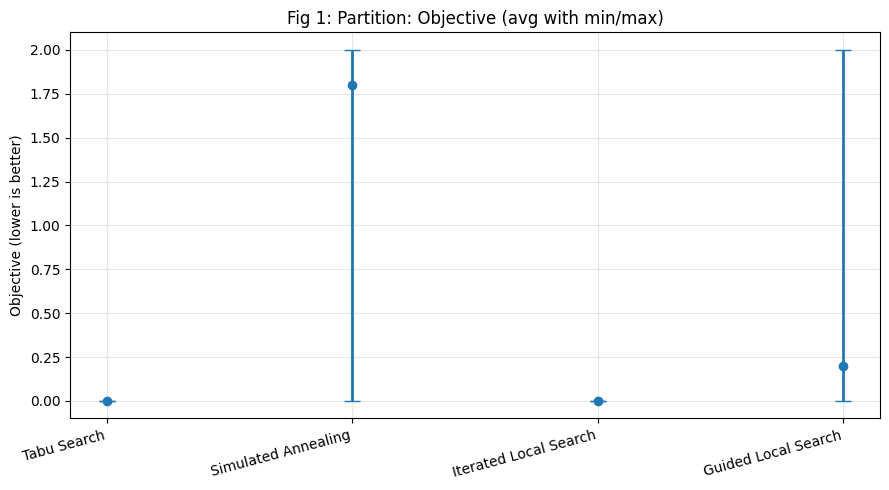

<Figure size 640x480 with 0 Axes>

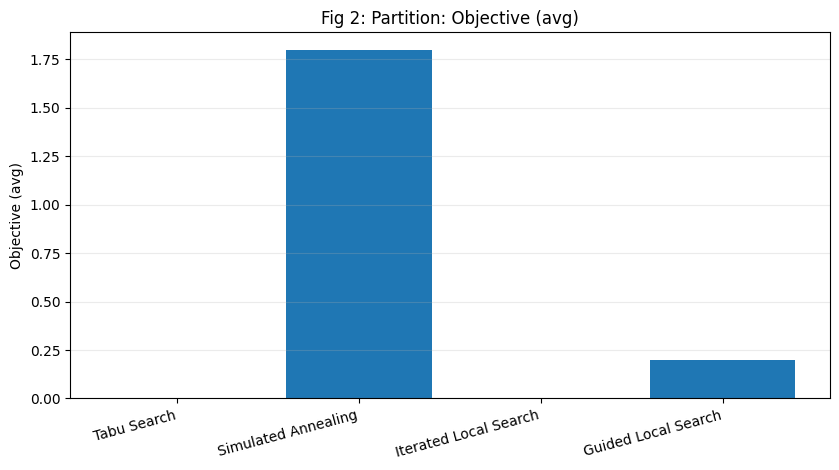

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_avg_with_min_max(
        df1, "Objective_avg", "Objective_min", "Objective_max",
        "Objective (lower is better)", "Fig 1: Partition: Objective (avg with min/max)",
        save_as="partition_objective_err.png"
    )

bar_plot(df1, "Objective_avg", "Objective (avg)", "Fig 2: Partition: Objective (avg)", "partition_objective_bar.png")


As shown in Figure 1 and 2, Average Objective value of the TS and ILS is zero throught all iterations. That means, those algorithms have been able to reach the best output value in every iteration. However, GLS and SA has been worse with a variation of the output value between 0 and 2 while GLS having a better average value out of the two.

The ranking of the algorithms according to the average memory usage is,

1. TS and ILS
3. GLS
4. SA

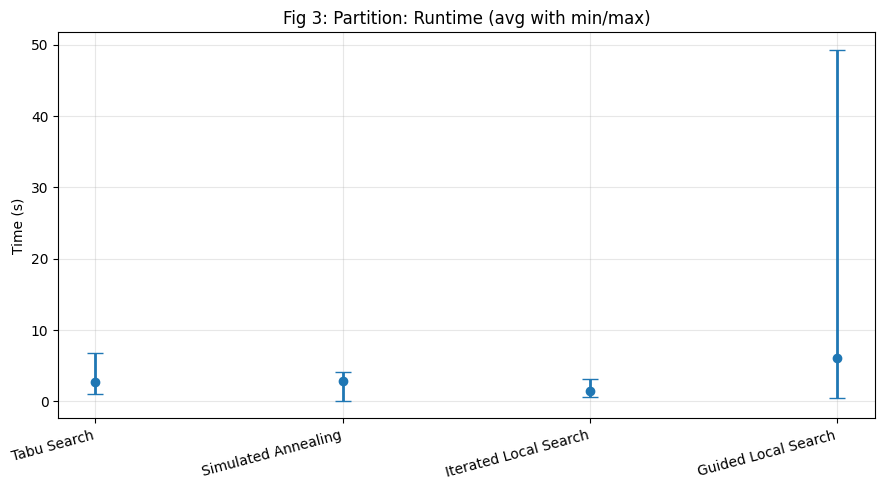

<Figure size 640x480 with 0 Axes>

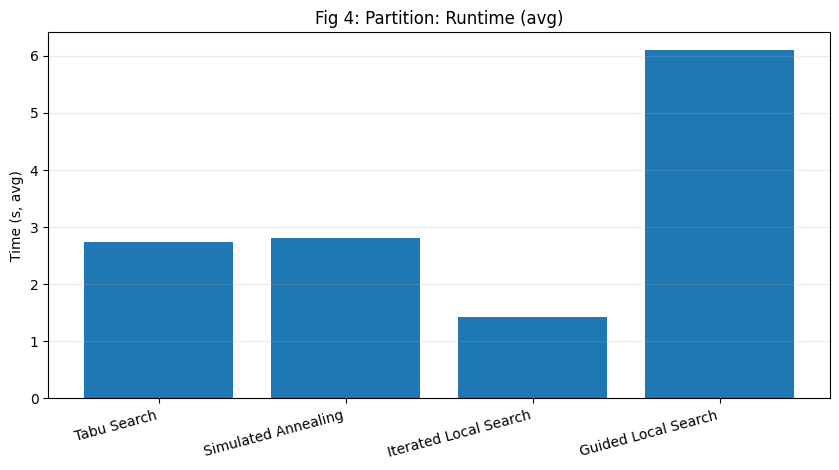

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_avg_with_min_max(
        df1, "Time_s_avg", "Time_s_min", "Time_s_max",
        "Time (s)", "Fig 3: Partition: Runtime (avg with min/max)",
        save_as="partition_runtime_err.png"
    )
bar_plot(df1, "Time_s_avg", "Time (s, avg)", "Fig 4: Partition: Runtime (avg)", "partition_runtime_bar.png")

Figure 3 shows that, run time of TS, SA, and ILS doesnt vary too much. However, GLS has a high variation of runtime within the iterations.

However according to the average runtime compared in figure 4, the algorithms can be ranked as below.

1. ILS
2. TS
3. SA
4. GLS

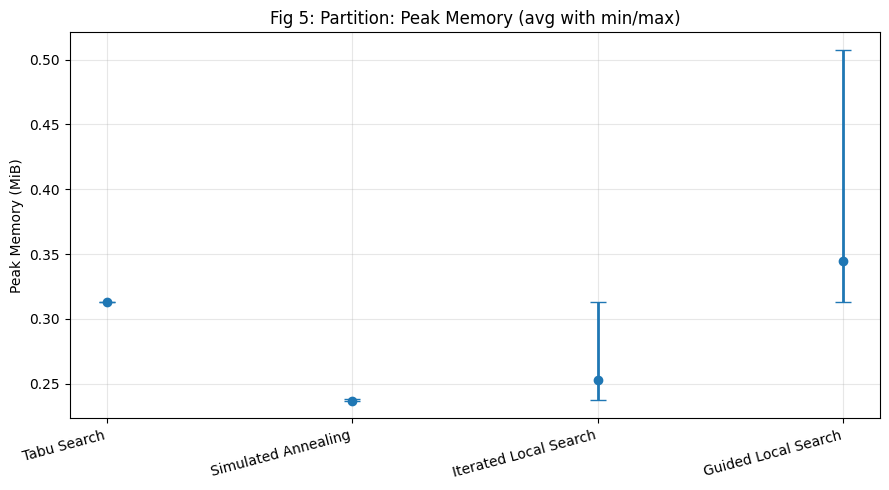

<Figure size 640x480 with 0 Axes>

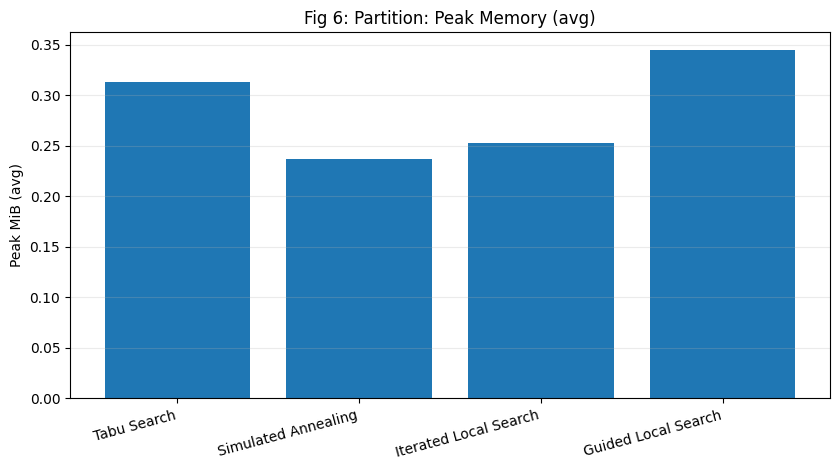

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_avg_with_min_max(
    df1, "PeakMiB_avg", "PeakMiB_min", "PeakMiB_max",
    "Peak Memory (MiB)", "Fig 5: Partition: Peak Memory (avg with min/max)",
    save_as="partition_memory_err.png"
        )
bar_plot(df1, "PeakMiB_avg", "Peak MiB (avg)", "Fig 6: Partition: Peak Memory (avg)", "partition_memory_bar.png")



As shown in Figure 5, with regard to the memory usage, there is a high variation during the  iterations in TS and GLS. However ILS have a smaller variation, and SA doesnt have any variation throughout.

Figure 6 shows that, according to the average memory usage within the iterations, the algorithms can be ranked as below.

1. SA
2. ILS
3. GLS
4. TS



Finally, by considering all the above factors, ILS has the best overall performance for the Partition problem, considering the result accuracy, time efficiency, and memory efficiency.

However, the worst algorithm out of the above for Partition problem can be considered as the GLS.

**3.2 Discusion of Results of Algorithms after Hyper Parameter Optimization(HPO).**

In [ ]:
# --Results (Optimized)--
# TS
mv, mt, mm = summarize(OPT_TS_RECS)
print_table("Optimized Tabu Search (Partition)", mv, mt, mm)

# SA
mv, mt, mm = summarize(OPT_SA_RECS)
print_table("Optimized Simulated Annealing (Partition)", mv, mt, mm)

# ILS
mv, mt, mm = summarize(OPT_ILS_RECS)
print_table("Optimized Iterated Local Search (Partition)", mv, mt, mm)

# GLS
mv, mt, mm = summarize(OPT_GLS_RECS)
print_table("Optimized Guided Local Search (Partition)", mv, mt, mm)


=== Optimized Tabu Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.308708 / 0.623600 / 0.438326
Peak MiB  : 0.313080 / 0.314055 / 0.313177

=== Optimized Simulated Annealing (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.026556 / 0.032836 / 0.028097
Peak MiB  : 0.236702 / 0.239053 / 0.237156

=== Optimized Iterated Local Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.409576 / 0.431517 / 0.421211
Peak MiB  : 0.312939 / 0.313931 / 0.313038

=== Optimized Guided Local Search (Partition) (min / max / avg) ===
Objective : 0.000000 / 0.000000 / 0.000000
Time [s]  : 0.148241 / 0.165116 / 0.154228
Peak MiB  : 0.313328 / 0.314255 / 0.313500


In [ ]:
# Collect available algorithm records from globals()
algo_vars = [
    ("Tabu Search",           "OPT_TS_RECS"),
    ("Simulated Annealing",   "OPT_SA_RECS"),
    ("Iterated Local Search", "OPT_ILS_RECS"),
    ("Guided Local Search",   "OPT_GLS_RECS"),
]

rows = []
missing = []
for label, varname in algo_vars:
    if varname in globals() and isinstance(globals()[varname], list) and len(globals()[varname]) > 0:
        mv, mt, mm = summarize(globals()[varname])  # uses your summarize()
        # mv/mt/mm are (min, max, avg) tuples
        rows.append({
            "Algorithm": label,
            "Objective_min": mv[0], "Objective_max": mv[1], "Objective_avg": mv[2],
            "Time_s_min":   mt[0], "Time_s_max":   mt[1], "Time_s_avg":   mt[2],
            "PeakMiB_min":  mm[0], "PeakMiB_max":  mm[1], "PeakMiB_avg":  mm[2],
        })
    else:
        missing.append(label)

# Build dataframe
df2 = pd.DataFrame(rows, columns=[
    "Algorithm",
    "Objective_min","Objective_max","Objective_avg",
    "Time_s_min","Time_s_max","Time_s_avg",
    "PeakMiB_min","PeakMiB_max","PeakMiB_avg",
])

display(df2)
if missing:
    print("Skipped (not found or empty):", ", ".join(missing))




,Algorithm,Objective_min,Objective_max,Objective_avg,Time_s_min,Time_s_max,Time_s_avg,PeakMiB_min,PeakMiB_max,PeakMiB_avg
0,Tabu Search,0.0,0.0,0.0,0.308708,0.623600,0.438326,0.313080,0.314055,0.313177
1,Simulated Annealing,0.0,0.0,0.0,0.026556,0.032836,0.028097,0.236702,0.239053,0.237156
2,Iterated Local Search,0.0,0.0,0.0,0.409576,0.431517,0.421211,0.312939,0.313931,0.313038
3,Guided Local Search,0.0,0.0,0.0,0.148241,0.165116,0.154228,0.313328,0.314255,0.313500


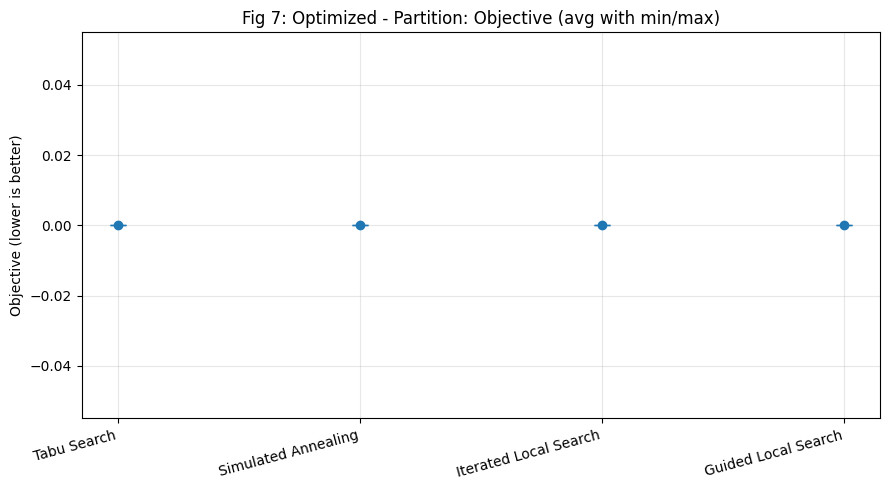

<Figure size 640x480 with 0 Axes>

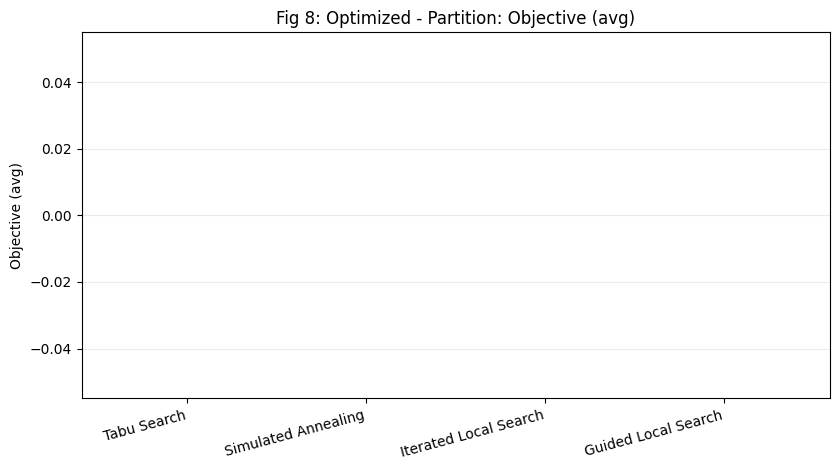

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_avg_with_min_max(
        df2, "Objective_avg", "Objective_min", "Objective_max",
        "Objective (lower is better)", "Fig 7: Optimized - Partition: Objective (avg with min/max)",
        save_as="partition_objective_err.png"
        )
bar_plot(df2, "Objective_avg", "Objective (avg)", "Fig 8: Optimized - Partition: Objective (avg)", "partition_objective_bar.png")

After optimization, all the algorithms have been able to reach the best possible objective value in each iteration which can be identified by the Figure 7 showing no variation of objective.

Moreover, Figure 8 shows that all algorithms have become equally capable of reaching the best possible objective value after optimization of parameters.

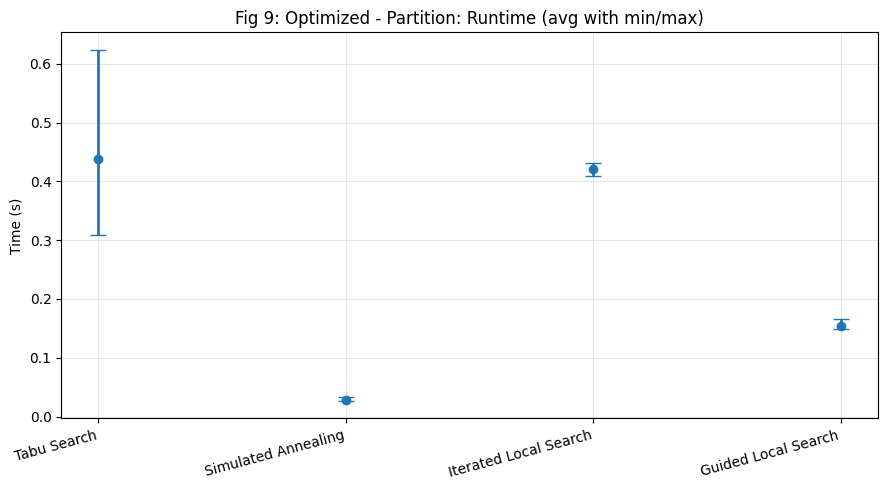

<Figure size 640x480 with 0 Axes>

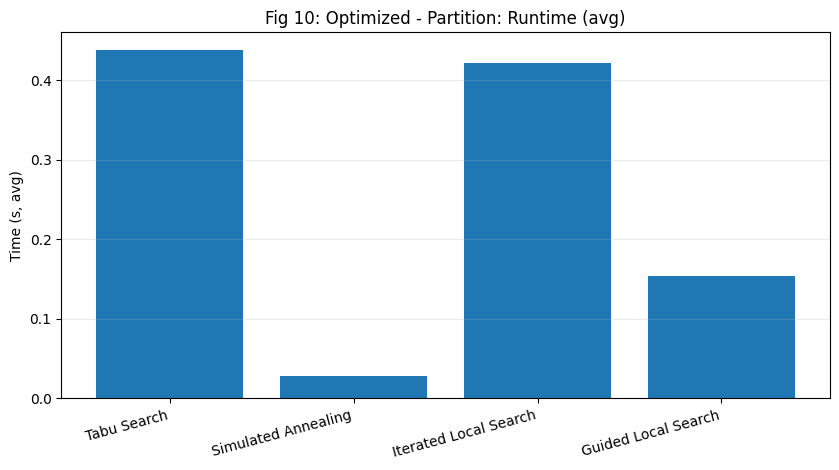

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_avg_with_min_max(
      df2, "Time_s_avg", "Time_s_min", "Time_s_max",
      "Time (s)", "Fig 9: Optimized - Partition: Runtime (avg with min/max)",
      save_as="partition_runtime_err.png"
      )
bar_plot(df2, "Time_s_avg", "Time (s, avg)", "Fig 10: Optimized - Partition: Runtime (avg)", "partition_runtime_bar.png")

After optimization, Figures 9 and 10 shows that SA and GLS have stuck to a consitent level of runtime efficiency with less variation. TS and ILS have a higher average runtime with a higher variation.

According to Figure 10, the algorithms can be ranked with respect to the average runtime efficiency as below.

1. SA
2. GLS
3. ILS
4. TS

**3.3 Improvement of the Algorithms after Hyper Parameter Optimization(HPO).**

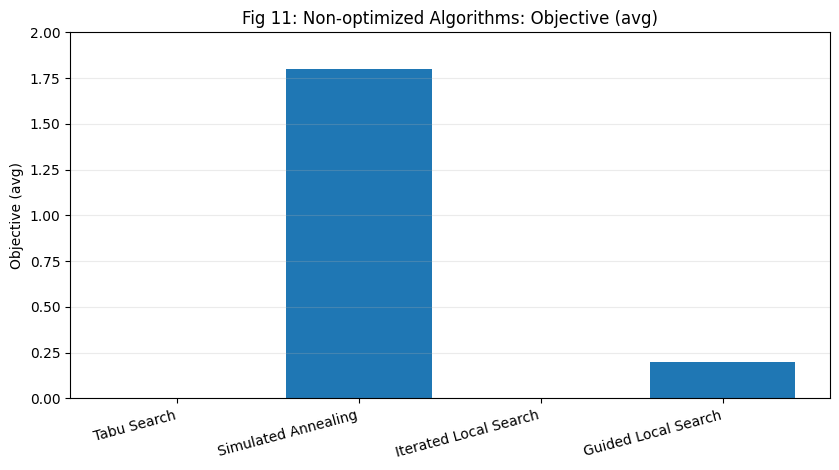

<Figure size 640x480 with 0 Axes>

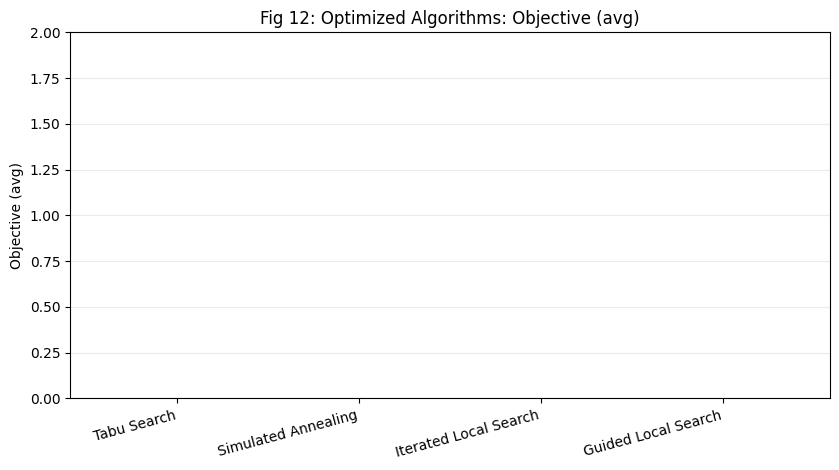

<Figure size 640x480 with 0 Axes>

In [ ]:
bar_plot(df1, "Objective_avg", "Objective (avg)", "Fig 11: Non-optimized Algorithms: Objective (avg)", "partition_objective_bar.png",ylim=(0, 2))
bar_plot(df2, "Objective_avg", "Objective (avg)", "Fig 12: Optimized Algorithms: Objective (avg)", "partition_objective_bar.png", ylim=(0, 2))

After HPO, all the algorithms have been able to reach the optimal objective value in each execution iteration. According to the Figures 11 and 12, a clear improvement of results of every algorithm can be seen.

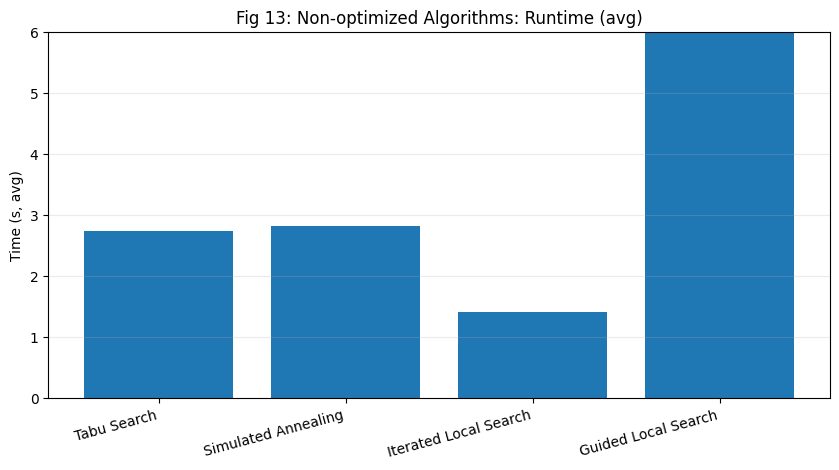

<Figure size 640x480 with 0 Axes>

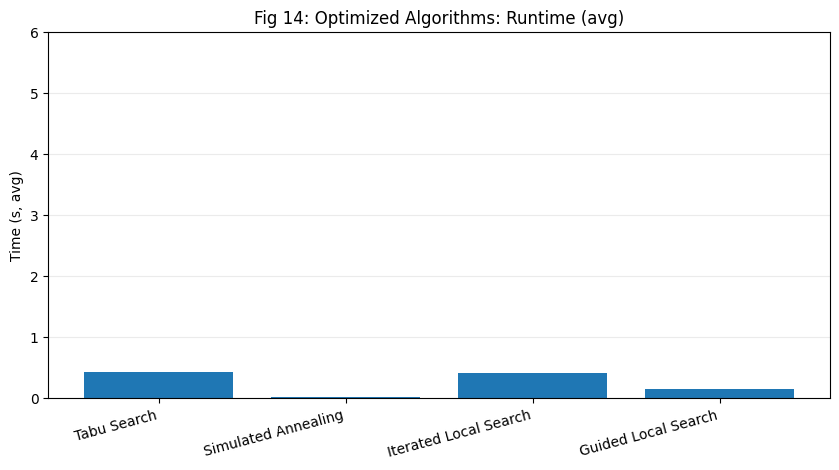

<Figure size 640x480 with 0 Axes>

In [ ]:
bar_plot(df1, "Time_s_avg", "Time (s, avg)", "Fig 13: Non-optimized Algorithms: Runtime (avg)", "partition_runtime_bar.png", ylim=(0, 6))
bar_plot(df2, "Time_s_avg", "Time (s, avg)", "Fig 14: Optimized Algorithms: Runtime (avg)", "partition_runtime_bar.png", ylim=(0, 6))

According to the Figures 13 and 14, sfter HPO, the average runtime of each algorithm has been clearly improved. Then the ranking of the average time-efficiency of each algorithms has changed to a different order by SA outperforming every other algorithms and reaching the best time-efficiency. Moreover, a highlighting factor is that GLS has improved to the 2nd best from the worst according to average time-efficiency after optimizing the parameters. Overall, all the algorithms has improved their runtime-efficiency by following the Hyper Parameter Optimization.

The new rankings are as follows.
1. SA
2. GLS
3. ILS
4. TS
